In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"..\data\raw\Spotify_Dataset_V3.csv", delimiter=";")

df.columns

Index(['Rank', 'Title', 'Artists', 'Date', 'Danceability', 'Energy',
       'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Valence', '# of Artist', 'Artist (Ind.)', '# of Nationality',
       'Nationality', 'Continent', 'Points (Total)',
       'Points (Ind for each Artist/Nat)', 'id', 'Song URL'],
      dtype='object')

In [2]:
# rename columns for consistency
df.rename(columns={'Title': 'track_name', 'id':'track_id', 'Artists': 'artist'}, inplace=True)

In [4]:
# Ensure date column is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by track + date
df = df.sort_values(['track_id', 'Date'])

# Compute consecutive days on chart for each track
df['rank_present'] = 1  # every row is a day in Top 200

# Group by track and compute longest chart streak
def longest_streak(x):
    # x is a series of ones by date; streaks = consecutive days
    return x.groupby((x != x.shift()).cumsum()).transform('size').max()

streaks = df.groupby('track_id')['rank_present'].apply(longest_streak)
df_tracks = streaks.reset_index().rename(columns={'rank_present':'longest_run'})

# Create target variable: sustained success = 56 days
df_tracks['sustained_success'] = (df_tracks['longest_run'] >= 56).astype(int)

dist = df_tracks['sustained_success'].value_counts(normalize=True) * 100
print("Distribution of Sustained Success (%) using number of days on chart >= 56 as threshold:")
print(dist)


Distribution of Sustained Success (%) using number of days on chart >= 56 as threshold:
sustained_success
0    74.697085
1    25.302915
Name: proportion, dtype: float64


In [5]:
weeks_per_song = df.groupby('track_id')['Date'].nunique().reset_index()
weeks_per_song.columns = ['track_id', 'total_weeks']

df_tracks_1 = df.merge(weeks_per_song, on='track_id', how='left')

df_tracks_1['sustained_success'] = (df_tracks_1['total_weeks'] >= 8).astype(int)

dist_1 = df_tracks_1['sustained_success'].value_counts(normalize=True) * 100
print("Distribution of Sustained Success (%) using number of weeks on chart >= 8 as threshold:")
print(dist_1)

Distribution of Sustained Success (%) using number of weeks on chart >= 8 as threshold:
sustained_success
1    97.734594
0     2.265406
Name: proportion, dtype: float64


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
if 'track_id' not in df.columns:
    df = df.rename(columns={'id': 'track_id'})
df['year'] = df['Date'].dt.isocalendar().year
df['week'] = df['Date'].dt.isocalendar().week

df_weekly = df.drop_duplicates(subset=['track_id', 'year', 'week'])

df_weekly = df_weekly.sort_values(['track_id', 'year', 'week'])

# Each weekly entry counts as one week on chart
df_weekly['week_present'] = 1

# Function: longest run of consecutive weeks
def longest_week_streak(group):
    # Compute whether current week is consecutive from previous
    consecutive = (group['week'].diff() == 1) & (group['year'].diff() == 0)

    # Mark starts of new streaks
    streak_id = (~consecutive).cumsum()

    # For each streak, compute streak length; return max
    return streak_id.value_counts().max()

# Compute longest weekly streak per track
streaks = df_weekly.groupby('track_id').apply(longest_week_streak)
df_tracks = streaks.reset_index().rename(columns={0: 'longest_run_weeks'})

# Create target variable: sustained success = greater than or equal to 8 weeks
df_tracks['sustained_success'] = (df_tracks['longest_run_weeks'] >= 8).astype(int)

# Class distribution
dist = df_tracks['sustained_success'].value_counts(normalize=True) * 100
print("Distribution of Sustained Success (%) using number of consecutive weeks on chart >= 8 as threshold:")
print(dist)


Distribution of Sustained Success (%) using number of consecutive weeks on chart >= 8 as threshold:
sustained_success
0    77.295055
1    22.704945
Name: proportion, dtype: float64


In [7]:
import pandas as pd

# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])
if 'track_id' not in df.columns:
    df = df.rename(columns={'id': 'track_id'})

df['week_start'] = df['Date'] - pd.to_timedelta(df['Date'].dt.weekday, unit='D')

df['week_index'] = (df['week_start'] - df['week_start'].min()) // pd.Timedelta(days=7)
df['week_index'] = df['week_index'].astype(int)

# Drop duplicates per track per week
df_weekly = df.drop_duplicates(subset=['track_id', 'week_index'])

df_weekly = df_weekly.sort_values(['track_id', 'week_index'])

# Consecutive-week streak calculation
def longest_week_streak(group):
    # Consecutive if the difference in week_index is exactly 1
    consecutive = (group['week_index'].diff() == 1)
    streak_id = (~consecutive).cumsum()
    return streak_id.value_counts().max()

# Compute longest streak per track
streaks = df_weekly.groupby('track_id').apply(longest_week_streak)
df_tracks = streaks.reset_index().rename(columns={0: 'longest_run_weeks'})

# Target: sustained success = 8 consecutive weeks
df_tracks['sustained_success'] = (df_tracks['longest_run_weeks'] >= 8).astype(int)

# Class distribution
dist = df_tracks['sustained_success'].value_counts(normalize=True) * 100
print("Distribution of Sustained Success (%) using number of consecutive weeks on chart >= 8 as threshold:")
print(dist)


Distribution of Sustained Success (%) using number of consecutive weeks on chart >= 8 as threshold:
sustained_success
0    74.828076
1    25.171924
Name: proportion, dtype: float64


In [8]:
df = df.merge(df_tracks[['track_id', 'sustained_success']], on='track_id', how='left')


In [9]:
audio_features = ["Danceability", "Loudness", "Valence", "Energy", "Acousticness"]

corr_results = df[audio_features + ["sustained_success"]].corr()['sustained_success'][audio_features]
print(corr_results)


Danceability    0.067316
Loudness        0.085804
Valence         0.025787
Energy          0.045741
Acousticness   -0.027682
Name: sustained_success, dtype: float64


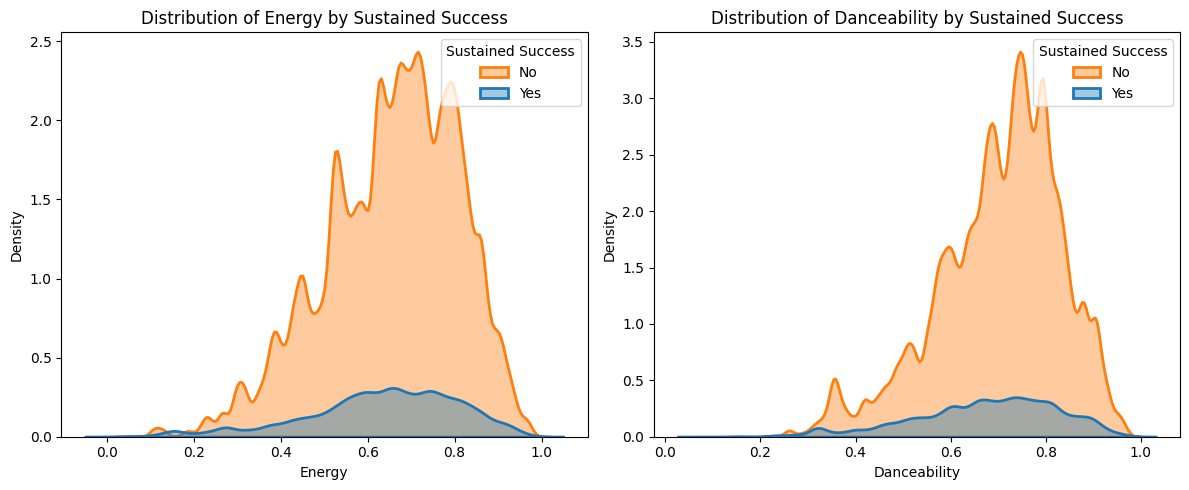

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# Left plot: Energy
plt.subplot(1,2,1)
sns.kdeplot(
    data=df, 
    x="Energy", 
    hue="sustained_success",
    fill=True, alpha=0.4, linewidth=2
)
plt.title("Distribution of Energy by Sustained Success")
plt.xlabel("Energy")
plt.ylabel("Density")
plt.legend(title="Sustained Success", labels=["No", "Yes"])

# Right plot: Danceability
plt.subplot(1,2,2)
sns.kdeplot(
    data=df, 
    x="Danceability", 
    hue="sustained_success",
    fill=True, alpha=0.4, linewidth=2
)
plt.title("Distribution of Danceability by Sustained Success")
plt.xlabel("Danceability")
plt.ylabel("Density")
plt.legend(title="Sustained Success", labels=["No", "Yes"])

plt.tight_layout()
plt.savefig(r"..\outputs\figures\sustained_success_distributions.png", dpi=300, bbox_inches='tight')
plt.savefig(r"..\outputs\figures\sustained_success_distributions.svg", format = 'svg', dpi=300, bbox_inches='tight')
plt.show()


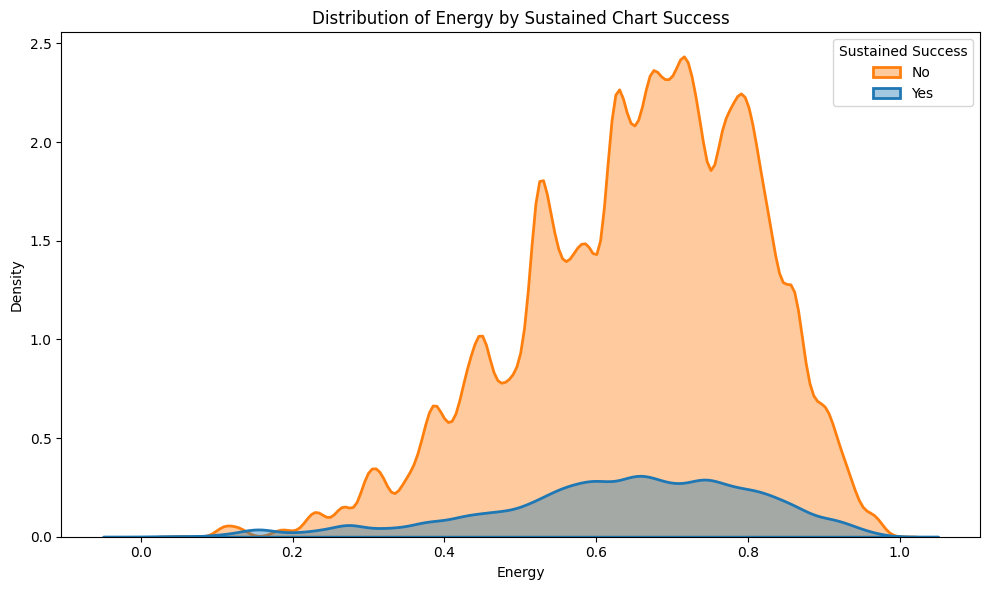

In [11]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df, 
    x="Energy", 
    hue="sustained_success",
    fill=True, alpha=0.4, linewidth=2
)

plt.title("Distribution of Energy by Sustained Chart Success")
plt.xlabel("Energy")
plt.ylabel("Density")
plt.legend(title="Sustained Success", labels=["No", "Yes"])
plt.tight_layout()
plt.show()
